In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
import emoji as emoji_lib
from scipy.stats import chi2_contingency
import torch
from torch import nn
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
import shutil
import os
import random
from sklearn.metrics import confusion_matrix, classification_report

C:\Users\LENOVO\DataspellProjects\BDC 2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.12.0.dev20260408+cu128
True
NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
train = pd.read_excel('case_1_labeled_data.xlsx')
test_df = pd.read_excel('case_1_text_to_predict.xlsx')

In [4]:
train.head(10)

,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik
5,@anakayahumi09 @irularr_ @ARSIPAJA Harus tetap...,Kualitas Pangan
6,🍱 Polsek Teluk Nibung monitoring Makan Bergizi...,Distribusi
7,eiw efisiensi tai nyusahin huwekk kemana duitn...,Anggaran
8,@kiharani Kesejahteraan petani naik karena MBG...,Ekonomi
9,@detikcom Ini lagi presiden main sandiwara.......,Sasaran Penerima


## Data Cleaning

#### Cek Duplikat

In [5]:
print(train.duplicated().sum())
print(train['full_text'].duplicated().sum())
# print(test.duplicated().sum())

1
1


In [6]:
train = train.drop_duplicates()

print(train.duplicated().sum())

0


In [7]:
def clean_tweet(text):
    text = re.sub(r"http\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = re.sub(r"#(\S+)", r"\1", text)
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [8]:
train['clean_text'] = train['full_text'].apply(clean_tweet)
train['clean_text'].head()

0    [user] pret. di sekolah gw dapet mbg tetep aja...
1    mbg bentuk penggarongan duit negara secara tsm...
2    [user] [user] pasal 34 ayat (1) undang-undang ...
3    makan bergizi gratis bikin masyarakat ngerasa ...
4    [user] presiden ngotot, paling sebel kalau mbg...
Name: clean_text, dtype: str

## EDA

In [9]:
train['label'].value_counts()

label
Kualitas Pangan     1246
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64

#### Panjang Token

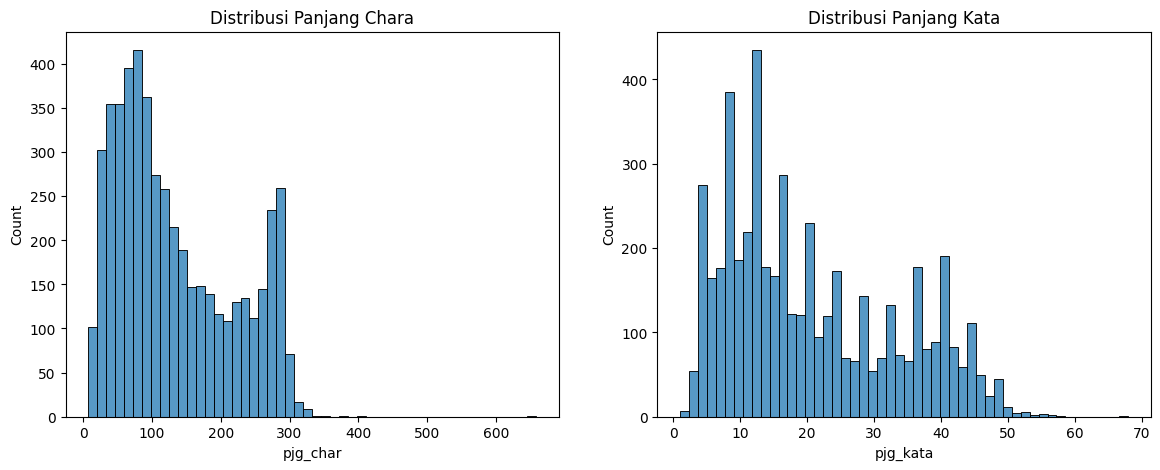

In [10]:
train['pjg_char'] = train['clean_text'].apply(len)
train['pjg_kata'] = train['clean_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(train['pjg_char'], bins=50, ax=axes[0])
axes[0].set_title("Distribusi Panjang Chara")


sns.histplot(train['pjg_kata'], bins=50, ax=axes[1])
axes[1].set_title("Distribusi Panjang Kata")

plt.show()

> Skew kanan banget, ini perlu key phrase(kata kunci) atau sesuatu yang bisa tambah representasinya

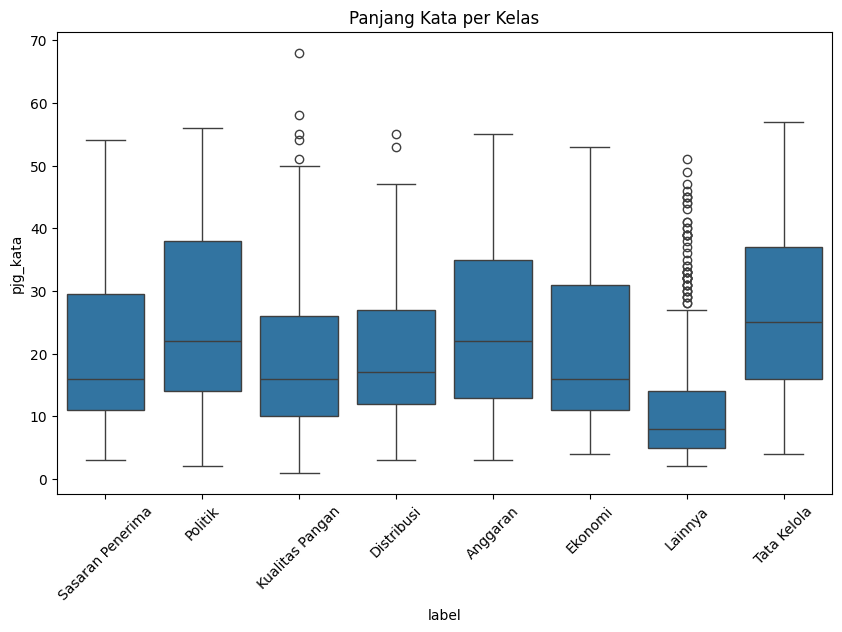

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(x='label', y='pjg_kata', data=train)
plt.xticks(rotation=45)
plt.title('Panjang Kata per Kelas')
plt.show()

> Dari rata-ratanya, semua label punya sedikit kata apakagi kelas "_lainnya_" paling sedikit sama kelas ini juga paling sedikit tweet jadi ada kemungkinan bakal ada model error dikelas yang ini.

#### Analisis N-Gram (Key Phrase)

> Berdasarkan pengalaman gen z, pasti ada key-phrase di Unigram, Bigram, sama Trigram seperti berikut:
- Unigram (kata tunggal): "anggaran", "gizi
- Bigram (2 kata): "salah sasaran"
- Trigram (3 kata): "makan bergizi gratis"

In [12]:
def cari_kata_berhadiah(df, n, top_kata=10, kolom='clean_text', label_col='label'):
    vec = TfidfVectorizer(
        ngram_range=(n, n),
        stop_words=["https","co","yg","dan","ga","untuk","mbg","di","ini","ke","itu","yang","ada","aja","apa","aku","bagaimana","dari","mau","ya","makan","bergizi","gratis", "user", "url", "nya"],
        max_features=5000
    )
    X = vec.fit_transform(df[kolom])
    feature_names = vec.get_feature_names_out()

    df_tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
    df_tfidf['label'] = df[label_col].values

    mean_tfidf = df_tfidf.groupby('label').mean()

    hasil = {}
    for kelas in mean_tfidf.index:
        row = mean_tfidf.loc[kelas].sort_values(ascending=False)
        top_ngrams = list(zip(row.index[:top_kata], row.values[:top_kata]))
        hasil[kelas] = top_ngrams
    return hasil

In [13]:
def plot_ngram_all_classes(df, n=2, top_kata=10, kolom='clean_text', label_col='label'):
    golden = cari_kata_berhadiah(df, n=n, top_kata=top_kata, kolom=kolom, label_col=label_col)
    daftar_label = list(golden.keys())

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for i, kelas in enumerate(daftar_label):
        ngrams, scores = zip(*golden[kelas]) if golden[kelas] else ([], [])
        df_plot = pd.DataFrame({'N-gram': ngrams, 'Skor TF-IDF': scores})

        sns.barplot(data=df_plot, x='Skor TF-IDF', y='N-gram',
                    hue='N-gram', palette='viridis', legend=False, ax=axes[i])
        axes[i].set_title(kelas, fontsize=12)
        axes[i].set_xlabel('Rata-rata TF-IDF')
        axes[i].set_ylabel('')

    plt.suptitle(f'Top {top_kata} {n}-gram Paling Khas per Kelas ', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

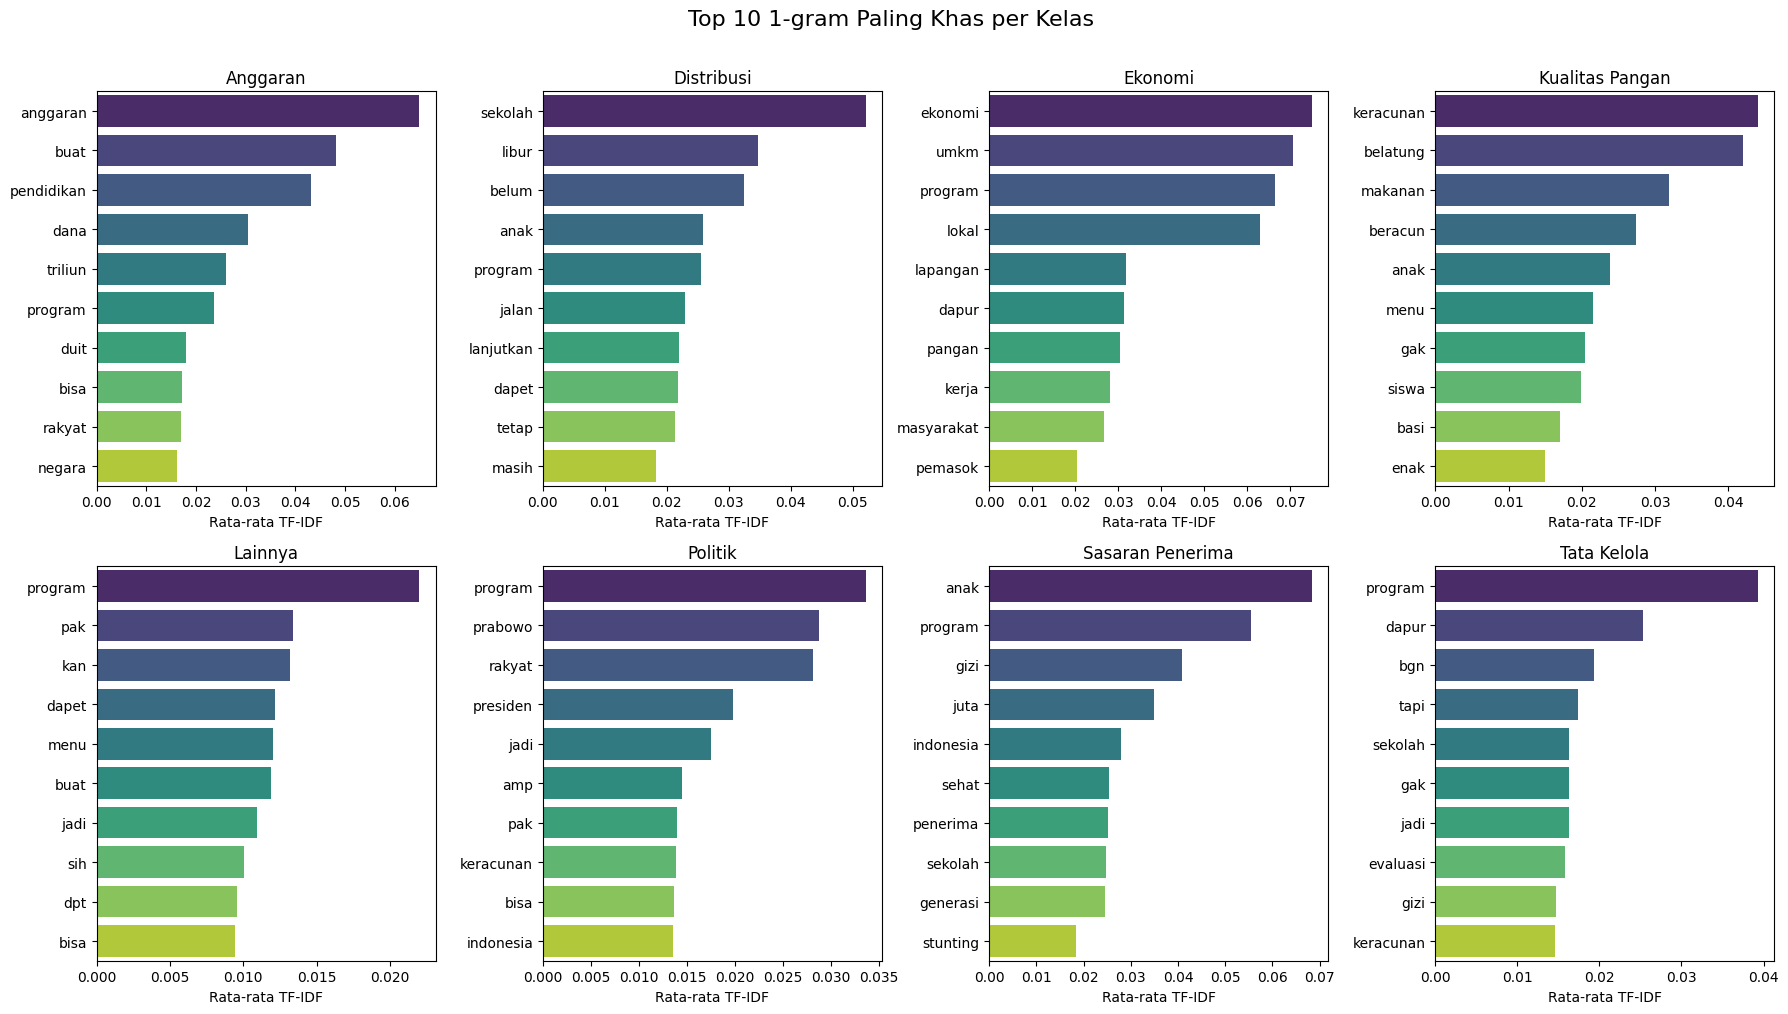

In [14]:
plot_ngram_all_classes(train, n=1, top_kata=10)   # unigram

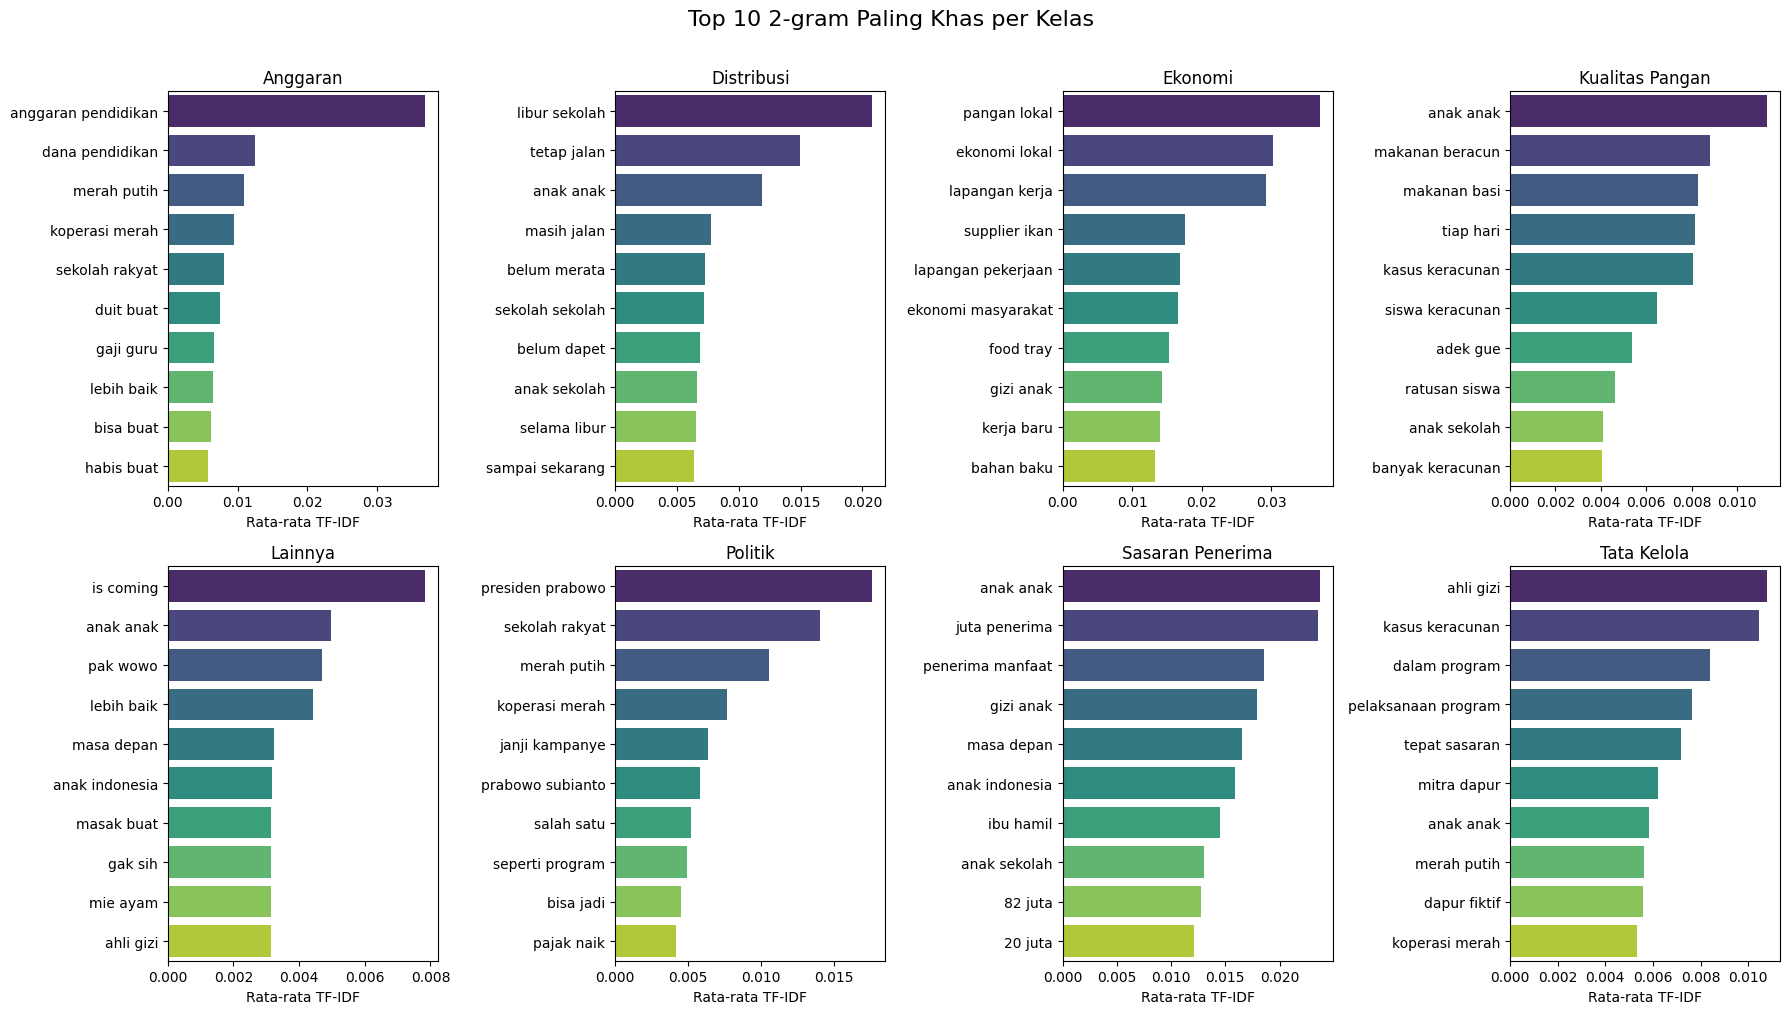

In [15]:
plot_ngram_all_classes(train, n=2, top_kata=10)   # bigram

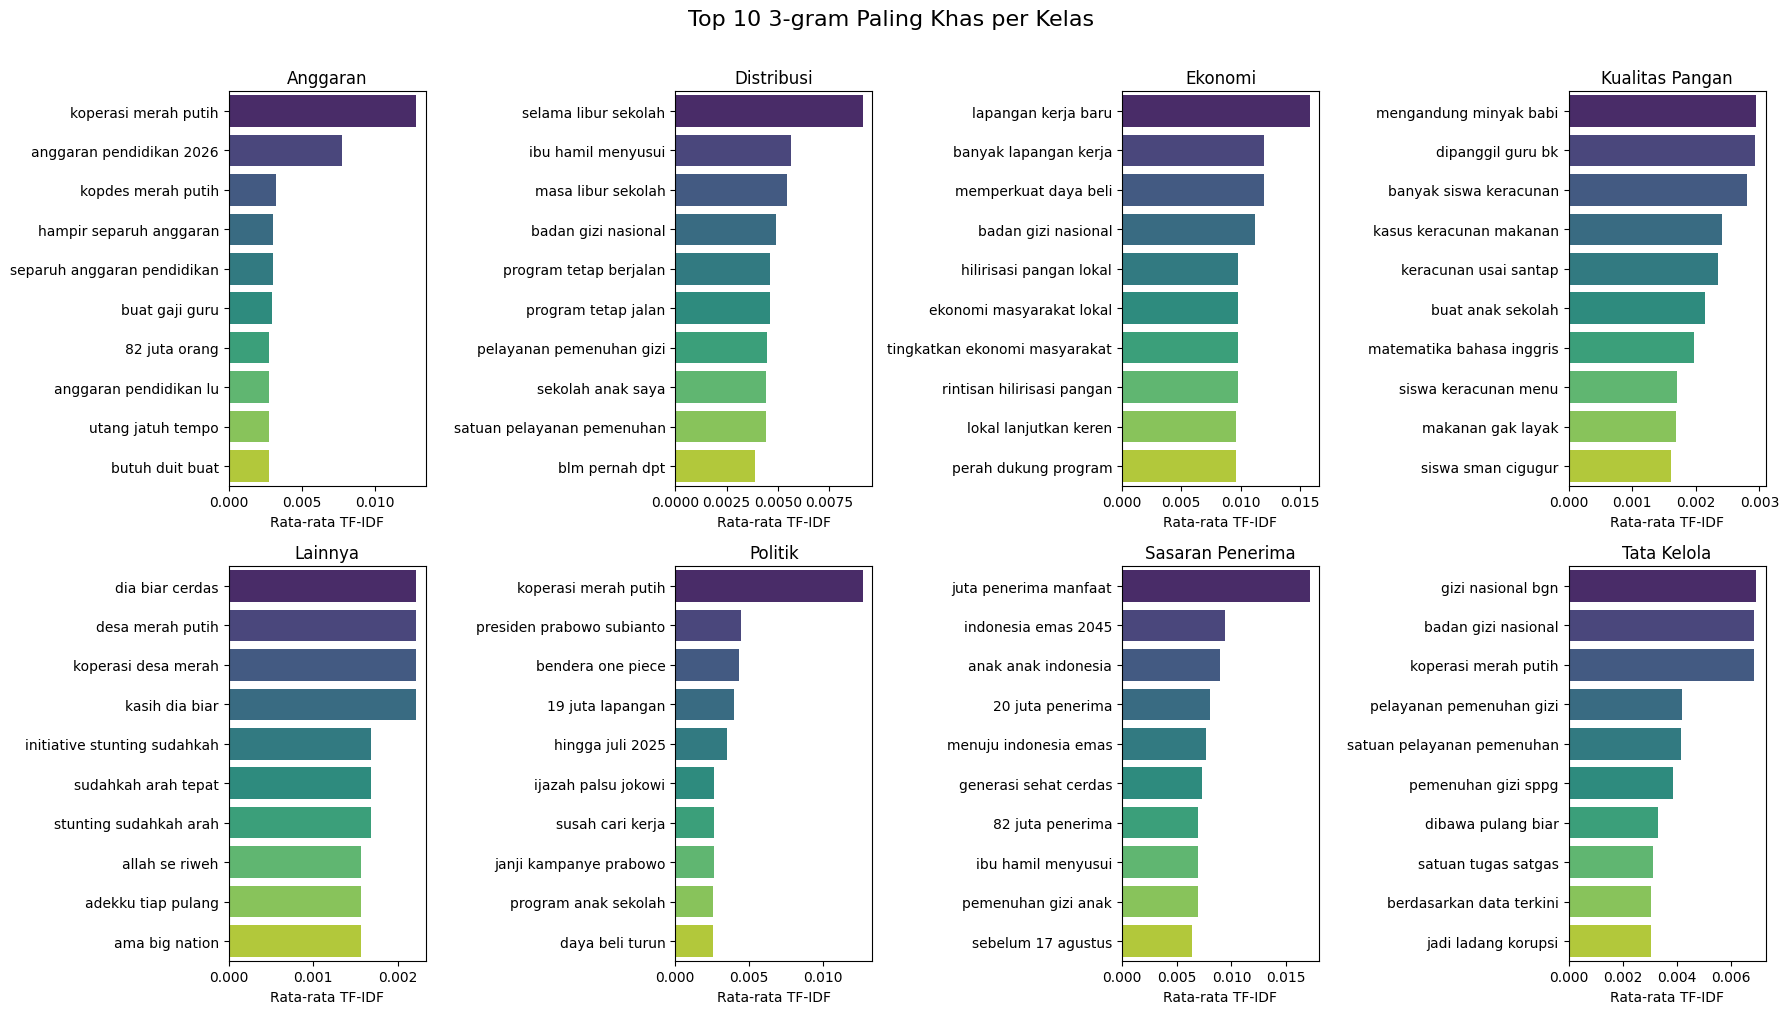

In [16]:
plot_ngram_all_classes(train, n=3, top_kata=10)   # trigram

In [17]:
def validasi_golden_words(df, n=1, top_kata=20, threshold_rasio=0.7, kolom='clean_text', label_col='label'):
    kandidat = cari_kata_berhadiah(df, n=n, top_kata=top_kata, kolom=kolom, label_col=label_col)

    vec_count = CountVectorizer(ngram_range=(n, n))
    X_count = vec_count.fit_transform(df[kolom])
    feature_names = vec_count.get_feature_names_out()
    df_count = pd.DataFrame(X_count.toarray(), columns=feature_names)
    df_count['label'] = df[label_col].values
    freq_per_kelas = df_count.groupby('label').sum()

    hasil = []
    for kelas, daftar in kandidat.items():
        for ngram, skor_tfidf in daftar:
            if ngram in freq_per_kelas.columns:
                frek_kelas = freq_per_kelas.loc[kelas, ngram] if kelas in freq_per_kelas.index else 0
                total_frek = freq_per_kelas[ngram].sum()
                rasio = frek_kelas / total_frek if total_frek > 0 else 0
                if rasio >= threshold_rasio:
                    hasil.append({
                        'Kelas': kelas,
                        'N-gram': ngram,
                        'TF-IDF': round(skor_tfidf, 4),
                        'Frekuensi': frek_kelas,
                        'Total Frek': total_frek,
                        'Rasio': round(rasio, 4)
                    })

    df_hasil = pd.DataFrame(hasil)
    df_hasil = df_hasil.sort_values(['Kelas', 'Rasio'], ascending=[True, False])
    return df_hasil

In [18]:
df_golden_unigram = validasi_golden_words(train, n=1, top_kata=20, threshold_rasio=0.7)
print(df_golden_unigram)

df_golden_bigram = validasi_golden_words(train, n=2, top_kata=20, threshold_rasio=0.7)

              Kelas      N-gram  TF-IDF  Frekuensi  Total Frek   Rasio
3          Anggaran     triliun  0.0261         92         104  0.8846
2          Anggaran        dana  0.0304        113         139  0.8129
4          Anggaran        2026  0.0149         47          58  0.8103
5          Anggaran          rp  0.0128         37          47  0.7872
0          Anggaran    anggaran  0.0650        266         351  0.7578
1          Anggaran  pendidikan  0.0431        172         245  0.7020
6        Distribusi       libur  0.0347         57          79  0.7215
9           Ekonomi         bri  0.0178          7           7  1.0000
8           Ekonomi     pemasok  0.0205          9          11  0.8182
7           Ekonomi        umkm  0.0706         36          50  0.7200
10  Kualitas Pangan    belatung  0.0420        112         138  0.8116
13  Kualitas Pangan        enak  0.0150         76          96  0.7917
11  Kualitas Pangan     beracun  0.0274         72          91  0.7912
12  Ku

In [19]:
df_golden_bigram[['Kelas','N-gram','Rasio']]

,Kelas,N-gram,Rasio
3,Anggaran,habis buat,1.00
5,Anggaran,anggaran buat,1.00
7,Anggaran,335 triliun,1.00
8,Anggaran,buat bayar,1.00
11,Anggaran,dana buat,1.00
...,...,...,...
61,Tata Kelola,dapur fiktif,1.00
64,Tata Kelola,ikut program,1.00
60,Tata Kelola,mitra dapur,0.80
62,Tata Kelola,ahli gizinya,0.80


#### Analisis Emoji

In [20]:
def ekstrak_emoji(teks):
    return [c for c in teks if c in emoji_lib.EMOJI_DATA]

In [21]:
train.iloc[6]

full_text     🍱 Polsek Teluk Nibung monitoring Makan Bergizi...
label                                                Distribusi
clean_text    🍱 polsek teluk nibung monitoring makan bergizi...
pjg_char                                                    210
pjg_kata                                                     33
Name: 6, dtype: object

In [22]:
for i in range(50):
    raw = train['clean_text'].iloc[i]
    emojis = ekstrak_emoji(raw)
    if emojis:
        print(f"Tweet {i}: {emojis}")

Tweet 0: ['🥲']
Tweet 6: ['🍱', '👦', '👧']
Tweet 16: ['🙂']
Tweet 25: ['🥰']
Tweet 29: ['🤣', '🫵', '🏻']
Tweet 30: ['😋', '😋', '👌', '🔥']
Tweet 32: ['😅']
Tweet 40: ['🤓', '😔', '✊', '🖐', '😹', '🖐']
Tweet 45: ['😑']
Tweet 47: ['😭', '👊']
Tweet 49: ['😭']


In [23]:
def emoji_per_kelas(df, kelas, top=10, kolom='clean_text'):
    teks_kelas = df[df['label'] == kelas][kolom]
    semua = []
    for t in teks_kelas:
        emoj_raw = ekstrak_emoji(t)
        # demojize supaya kebaca di plot
        emoj_text = [emoji_lib.demojize(e) for e in emoj_raw]
        semua.extend(emoj_text)
    counter = Counter(semua)
    return counter.most_common(top)

In [24]:
def plot_emoji_per_kelas(df, kelas, top=10, kolom='clean_text'):
    hasil = emoji_per_kelas(df, kelas, top, kolom)
    if not hasil:
        print(f"Kelas '{kelas}' tidak memiliki emoji yang cukup.")
        return None
    df_plot = pd.DataFrame(hasil, columns=['Emoji', 'Frekuensi'])

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_plot, x='Frekuensi', y='Emoji',
                hue='Emoji', palette='viridis', legend=False)
    plt.title(f'Top {top} Emoji untuk kelas: {kelas}')
    plt.tight_layout()
    plt.show()
    return df_plot

In [25]:
def plot_emoji_semua(df, top=10, kolom='clean_text'):
    daftar_label = df['label'].unique()
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for i, kelas in enumerate(daftar_label):
        hasil = emoji_per_kelas(df, kelas, top, kolom)
        if hasil:
            df_plot = pd.DataFrame(hasil, columns=['Emoji', 'Frekuensi'])
            sns.barplot(data=df_plot, x='Frekuensi', y='Emoji',
                        hue='Emoji', palette='viridis', legend=False, ax=axes[i])
            axes[i].set_title(kelas, fontsize=12)
        else:
            axes[i].text(0.5, 0.5, 'Tidak ada emoji', ha='center', va='center')
        axes[i].set_ylabel('')

    plt.suptitle(f'Top {top} Emoji per Kelas (dari Teks Asli)', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [26]:
def emoji_matrix(df, top_global=30, kolom='clean_text'):
    daftar_label = df['label'].unique()

    counter_global = Counter()
    for t in df[kolom]:
        emoj_raw = ekstrak_emoji(t)
        emoj_text = [emoji_lib.demojize(e) for e in emoj_raw]
        counter_global.update(emoj_text)
    top_emoji = [e for e, _ in counter_global.most_common(top_global)]

    matriks = []
    for emo_teks in top_emoji:
        row = {'emoji': emo_teks}
        for kelas in daftar_label:
            teks_kelas = df[df['label'] == kelas][kolom]
            count = 0
            for t in teks_kelas:
                t_demojized = emoji_lib.demojize(t)
                if emo_teks in t_demojized:
                    count += 1
            row[kelas] = count
        matriks.append(row)

    return pd.DataFrame(matriks)

def plot_emoji_heatmap(df, top_global=30, kolom='clean_text'):
    df_mat = emoji_matrix(df, top_global, kolom)
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_mat.set_index('emoji'), annot=True, cmap='YlGnBu')
    plt.title('Frekuensi Kemunculan Emoji per Kelas')
    plt.tight_layout()
    plt.show()
    return df_mat

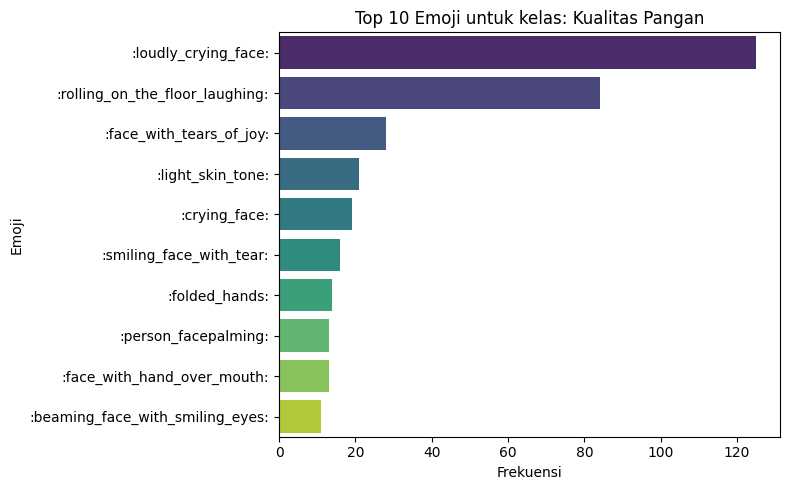

,Emoji,Frekuensi
0,:loudly_crying_face:,125
1,:rolling_on_the_floor_laughing:,84
2,:face_with_tears_of_joy:,28
3,:light_skin_tone:,21
4,:crying_face:,19
5,:smiling_face_with_tear:,16
6,:folded_hands:,14
7,:person_facepalming:,13
8,:face_with_hand_over_mouth:,13
9,:beaming_face_with_smiling_eyes:,11


In [27]:
plot_emoji_per_kelas(train, "Kualitas Pangan", top=10, kolom='clean_text')

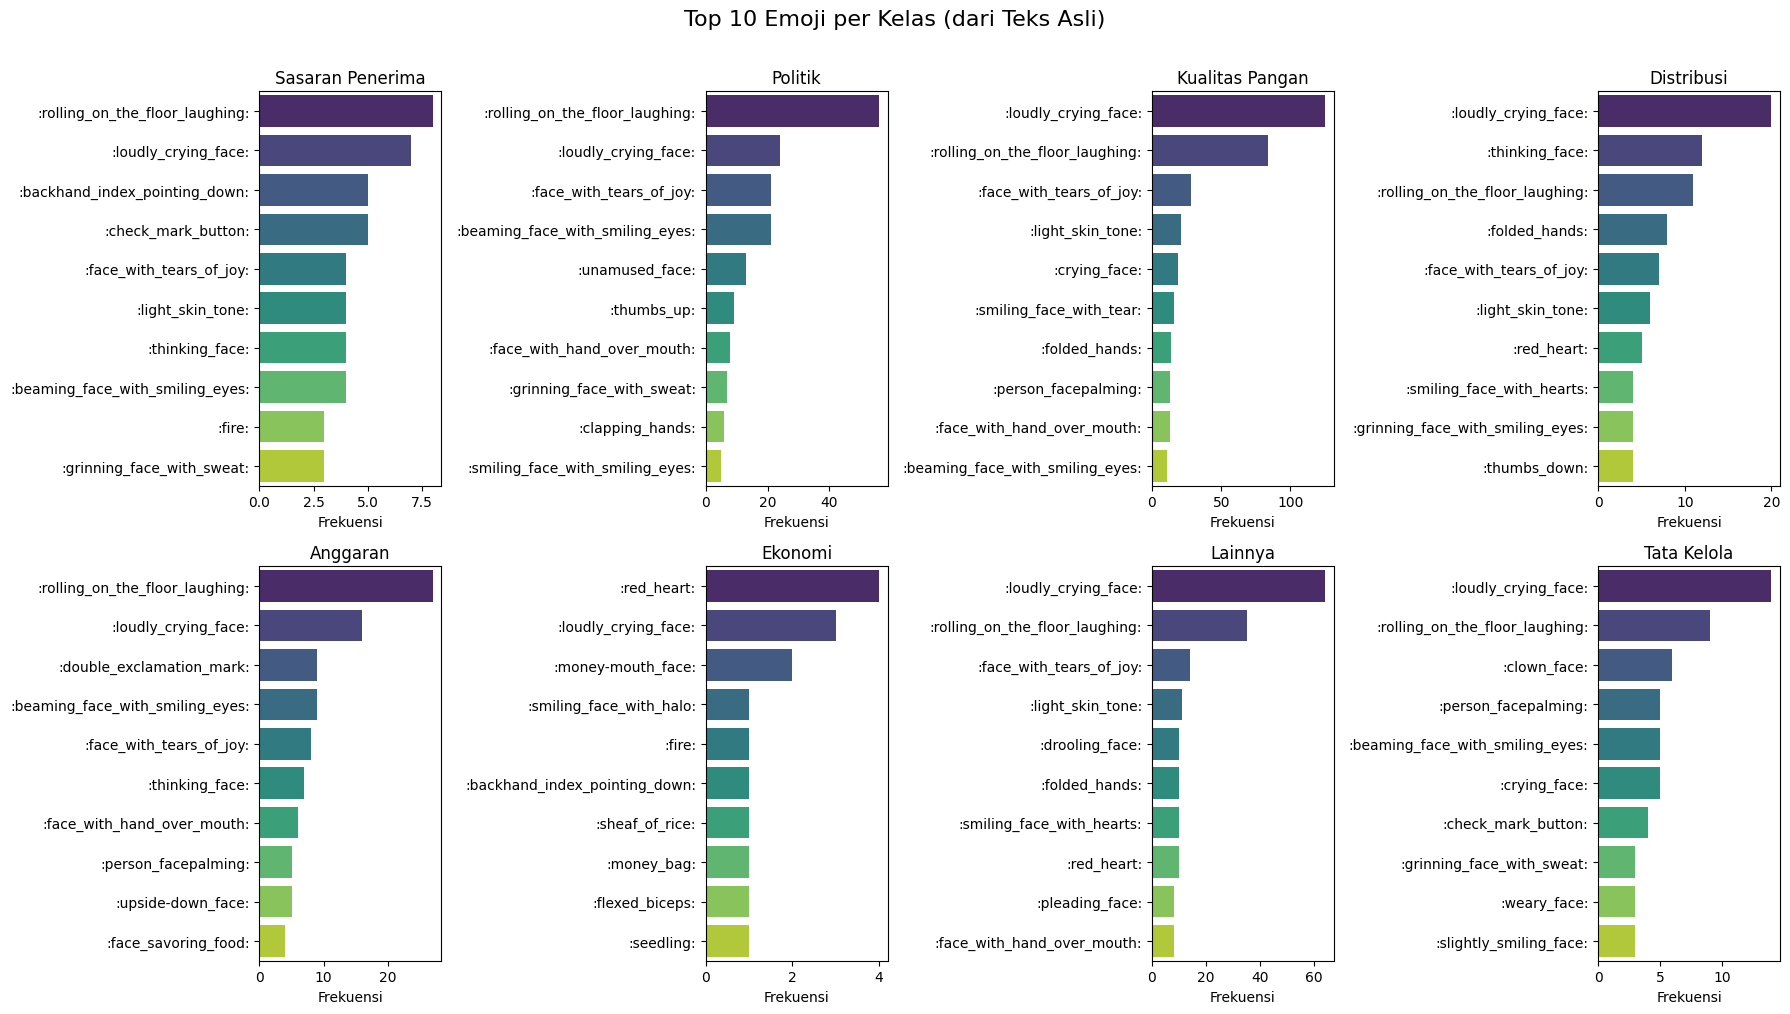

In [28]:
plot_emoji_semua(train, top=10, kolom='clean_text')

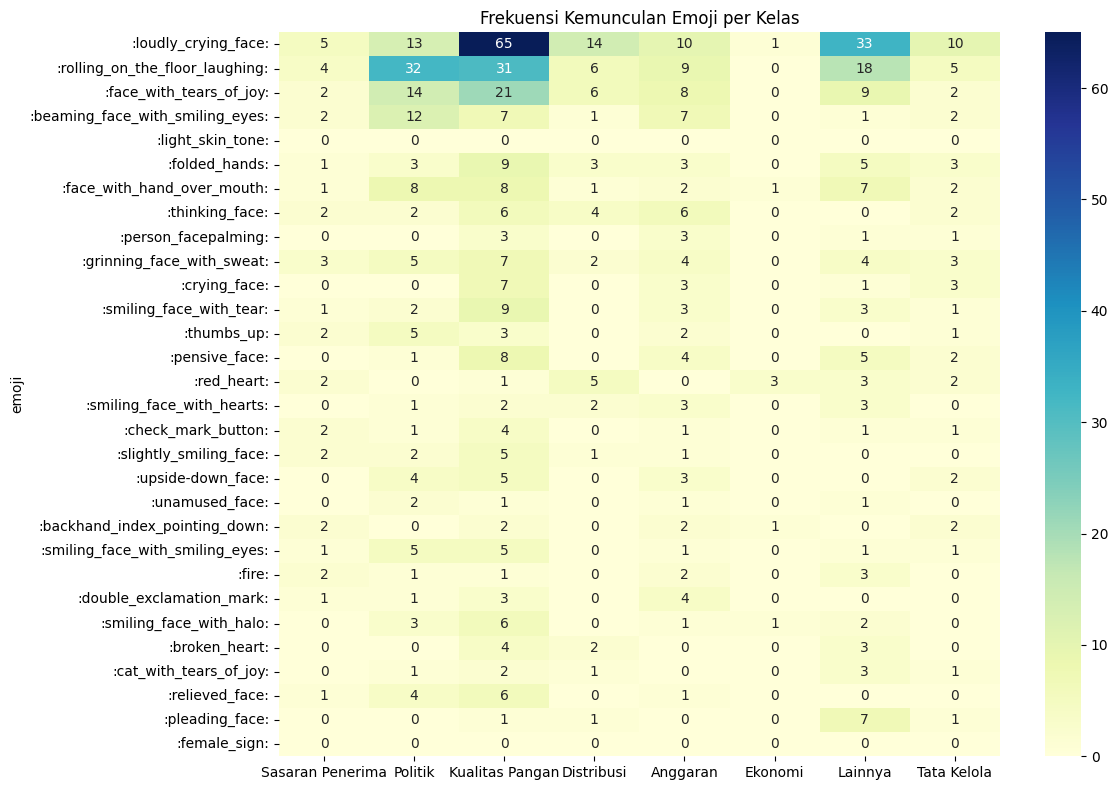

In [29]:
df_heat = plot_emoji_heatmap(train, top_global=30, kolom='clean_text')

> Gak bisa jadi interpretasi prediksi kelas (model) sih ini, cuma bisa jadi analisis tweetnya (sentimen terhadap kelasnya)

#### Analisis Mention dan URL

In [30]:
train['has_mention'] = train['full_text'].str.contains(r'@\w+', regex=True).astype(int)
train['has_url'] = train['full_text'].str.contains(r'http\S+', regex=True).astype(int)

mention_per_kelas = train.groupby('label')['has_mention'].mean() * 100
url_per_kelas = train.groupby('label')['has_url'].mean() * 100

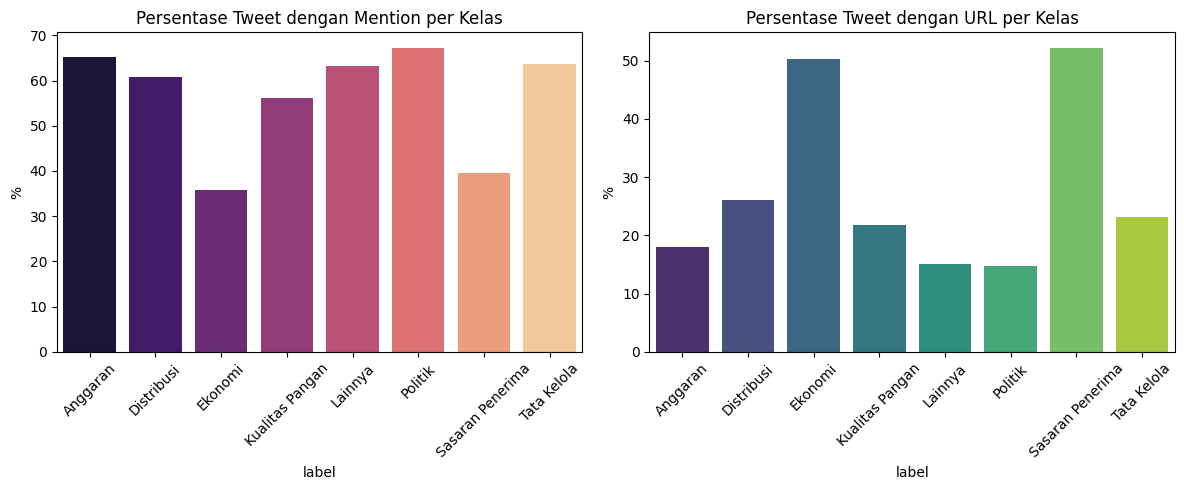

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=mention_per_kelas.index, y=mention_per_kelas.values,
            hue=mention_per_kelas.index, palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Persentase Tweet dengan Mention per Kelas')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=url_per_kelas.index, y=url_per_kelas.values,
            hue=url_per_kelas.index, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Persentase Tweet dengan URL per Kelas')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
def chi2_test(feature, label_col='label'):
    tabel = pd.crosstab(train[label_col], train[feature])
    chi2, p, dof, expected = chi2_contingency(tabel)
    print(f"Chi-Square test untuk {feature}: p-value = {p:.75f}")
    if p < 0.05:
        print(f"  = Ada hubungan signifikan antara {feature} dan label.")
    else:
        print(f"  = Tidak ada hubungan signifikan antara {feature} dan label.")
    return p

p_mention = chi2_test('has_mention')
print()
p_url = chi2_test('has_url')

Chi-Square test untuk has_mention: p-value = 0.000000000000000000000000000000239964753150204086235019793526310534311412599
  = Ada hubungan signifikan antara has_mention dan label.

Chi-Square test untuk has_url: p-value = 0.000000000000000000000000000000000000000000000000000000000000000000000000007
  = Ada hubungan signifikan antara has_url dan label.


## Model

In [33]:
for fold in range(1, 6):
    results_path = f'./results_fold_{fold}'
    if os.path.exists(results_path):
        shutil.rmtree(results_path)
        print(f"Hapus {results_path}")

    best_path = f'./best_model_fold_{fold}'
    if os.path.exists(best_path):
        shutil.rmtree(best_path)
        print(f"Hapus {best_path}")


Hapus ./results_fold_1


mungkin bisadicoba pake https://huggingface.co/cahya/roberta-base-indonesian-522M

In [34]:
# enkoding label
label_list = sorted(train['label'].unique())
label2id = {l:i for i, l in enumerate(label_list)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(label2id)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"{label2id},\n {num_labels},\n {id2label}")

Using device: cuda
{'Anggaran': 0, 'Distribusi': 1, 'Ekonomi': 2, 'Kualitas Pangan': 3, 'Lainnya': 4, 'Politik': 5, 'Sasaran Penerima': 6, 'Tata Kelola': 7},
 8,
 {0: 'Anggaran', 1: 'Distribusi', 2: 'Ekonomi', 3: 'Kualitas Pangan', 4: 'Lainnya', 5: 'Politik', 6: 'Sasaran Penerima', 7: 'Tata Kelola'}


In [35]:
X = train['clean_text'].values
y = np.array([label2id[l] for l in train['label']])

In [36]:
golden_per_kelas = df_golden_bigram.groupby('Kelas')['N-gram'].apply(list).to_dict()

threshold = 500
X_aug = []
y_aug = []

for label_name in label_list:
    mask = train['label'] == label_name
    texts = X[mask].tolist()
    labels = y[mask].tolist()
    count = len(texts)

    if count < threshold:
        needed = threshold - count
        print(f"Augmentasi {label_name}: {count} → {count + needed}")
        golden_words = golden_per_kelas.get(label_name, [])
        aug_texts = []
        while len(aug_texts) < needed:
            for t in texts:
                if len(aug_texts) >= needed:
                    break
                if golden_words:
                    chosen_gw = random.choice(golden_words)
                    varian = f"{t}. {chosen_gw}."
                else:
                    varian = t
                aug_texts.append(varian)
        all_texts = texts + aug_texts[:needed]
        all_labels = labels + [labels[0]] * needed
        X_aug.extend(all_texts)
        y_aug.extend(all_labels)
    else:
        X_aug.extend(texts)
        y_aug.extend(labels)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("\nDistribusi setelah augmentasi:")
for i, nama in id2label.items():
    print(f"{nama}: {np.sum(y_aug == i)}")

Augmentasi Distribusi: 433 → 500
Augmentasi Ekonomi: 145 → 500

Distribusi setelah augmentasi:
Anggaran: 727
Distribusi: 500
Ekonomi: 500
Kualitas Pangan: 1246
Lainnya: 638
Politik: 792
Sasaran Penerima: 507
Tata Kelola: 511


In [37]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')

In [38]:
print("Distribusi label per fold:\n")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    y_train, y_val = y[train_idx], y[val_idx]

    print(f"Fold {fold+1}")
    print(f"  Train: {len(y_train)} sampel")
    for i, nama in id2label.items():
        count = np.sum(y_train == i)
        print(f"    {nama}: {count}")

    print(f"  Validasi: {len(y_val)} sampel")
    for i, nama in id2label.items():
        count = np.sum(y_val == i)
        print(f"    {nama}: {count}")
    print()

Distribusi label per fold:

Fold 1
  Train: 3999 sampel
    Anggaran: 582
    Distribusi: 346
    Ekonomi: 116
    Kualitas Pangan: 997
    Lainnya: 510
    Politik: 634
    Sasaran Penerima: 405
    Tata Kelola: 409
  Validasi: 1000 sampel
    Anggaran: 145
    Distribusi: 87
    Ekonomi: 29
    Kualitas Pangan: 249
    Lainnya: 128
    Politik: 158
    Sasaran Penerima: 102
    Tata Kelola: 102

Fold 2
  Train: 3999 sampel
    Anggaran: 582
    Distribusi: 346
    Ekonomi: 116
    Kualitas Pangan: 997
    Lainnya: 510
    Politik: 634
    Sasaran Penerima: 405
    Tata Kelola: 409
  Validasi: 1000 sampel
    Anggaran: 145
    Distribusi: 87
    Ekonomi: 29
    Kualitas Pangan: 249
    Lainnya: 128
    Politik: 158
    Sasaran Penerima: 102
    Tata Kelola: 102

Fold 3
  Train: 3999 sampel
    Anggaran: 582
    Distribusi: 346
    Ekonomi: 116
    Kualitas Pangan: 997
    Lainnya: 510
    Politik: 633
    Sasaran Penerima: 406
    Tata Kelola: 409
  Validasi: 1000 sampel
    Anggaran:

In [39]:
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self,texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [40]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            at = self.alpha[targets]
            focal_loss = at * focal_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [41]:
def train_one_fold(fold, train_idx, val_idx, X, y):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1}")
    print(f"{'='*60}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')
    model = AutoModelForSequenceClassification.from_pretrained(
        'indolem/indobertweet-base-uncased',
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
        classifier_dropout=0.3,
    )
    model.to(device)

    train_dataset = TweetDataset(X_train, y_train, tokenizer)
    val_dataset   = TweetDataset(X_val,   y_val,   tokenizer)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    class FocalTrainer(Trainer):
        def __init__(self, *args, alpha=None, gamma=2.0, **kwargs):
            super().__init__(*args, **kwargs)
            self.focal_loss = FocalLoss(alpha=alpha, gamma=gamma)

        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop('labels')
            outputs = model(**inputs)
            logits = outputs.logits
            loss = self.focal_loss(logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = balanced_accuracy_score(labels, preds)
        return {'balanced_accuracy': acc}

    training_args = TrainingArguments(
        output_dir=f'./results_fold_{fold}',
        num_train_epochs=10,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='balanced_accuracy',
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to='none',
    )

    trainer = FocalTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        alpha=class_weights,
        gamma=2.0,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    val_metrics = trainer.evaluate(val_dataset)
    val_balanced_acc = val_metrics['eval_balanced_accuracy']

    train_metrics = trainer.evaluate(train_dataset)
    train_balanced_acc = train_metrics['eval_balanced_accuracy']

    print(f"Fold {fold+1} - Train Balanced Accuracy: {train_balanced_acc:.4f}")
    print(f"Fold {fold+1} - Valid Balanced Accuracy: {val_balanced_acc:.4f}")
    trainer.save_model(f"./model_fold_{fold}")
    return train_balanced_acc, val_balanced_acc

In [42]:
# train_scores = []
# val_scores = []
#
# for fold, (train_idx, val_idx) in enumerate(skf.split(X_aug, y_aug)):
#     train_acc, val_acc = train_one_fold(fold, train_idx, val_idx, X_aug, y_aug)
#     train_scores.append(train_acc)
#     val_scores.append(val_acc)
#
# print(f"\nRata-rata Train: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
# print(f"Rata-rata Valid: {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")

In [43]:
train_scores = []
val_scores = []
all_val_indices = []
all_val_preds = []
all_val_labels = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_aug, y_aug)):
    train_acc, val_acc = train_one_fold(fold, train_idx, val_idx, X_aug, y_aug)
    train_scores.append(train_acc)
    val_scores.append(val_acc)
    all_val_indices.extend(val_idx)
    model = AutoModelForSequenceClassification.from_pretrained(f"./model_fold_{fold}")
    model.to(device)
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')
    val_dataset = TweetDataset(X_aug[val_idx], y_aug[val_idx], tokenizer)

    preds = []
    with torch.no_grad():
        for batch in torch.utils.data.DataLoader(val_dataset, batch_size=64):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            preds.extend(np.argmax(outputs.logits.cpu().numpy(), axis=1))
    all_val_preds.extend(preds)
    all_val_labels.extend(y_aug[val_idx])

print(f"\nRata-rata Train: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Rata-rata Valid: {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")


  FOLD 1


[transformers] You passed `num_labels=8` which is incompatible to the `id2label` map of length `2`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33231.14it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; 

Epoch,Training Loss,Validation Loss,Balanced Accuracy
1,0.933371,0.602769,0.670629
2,0.523120,0.526211,0.700807
3,0.361812,0.501425,0.717505
4,0.260094,0.518482,0.710482
5,0.172513,0.539588,0.707297


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it]


Training Loss,Validation Loss,Epoch,Balanced Accuracy
0.172513,0.501425,5,0.717505


...

Training Loss,Validation Loss,Epoch,Balanced Accuracy
0.171816,0.565045,5,0.707469


Training Loss,Validation Loss,Epoch,Balanced Accuracy
0.171816,0.206808,5,0.880036


Fold 5 - Train Balanced Accuracy: 0.8800
Fold 5 - Valid Balanced Accuracy: 0.7075


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7314.19it/s]



Rata-rata Train: 0.9218 ± 0.0394
Rata-rata Valid: 0.7095 ± 0.0084


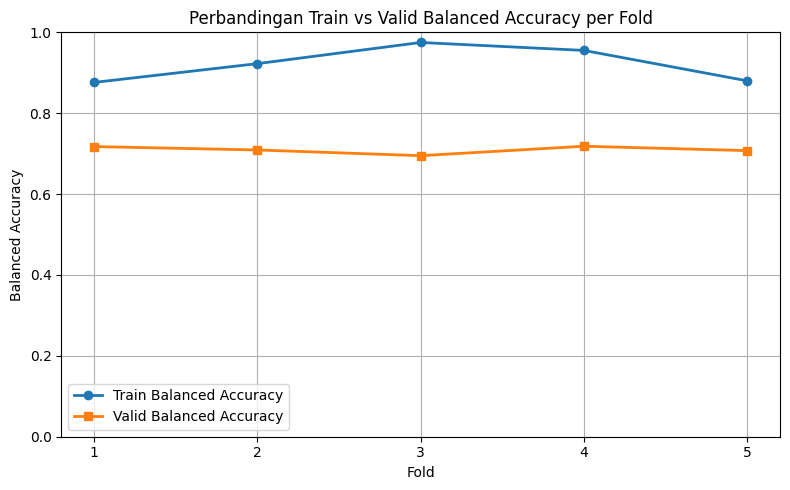

In [44]:
folds = range(1, 6)
plt.figure(figsize=(8, 5))
plt.plot(folds, train_scores, marker='o', linewidth=2, label='Train Balanced Accuracy')
plt.plot(folds, val_scores, marker='s', linewidth=2, label='Valid Balanced Accuracy')
plt.xlabel('Fold')
plt.ylabel('Balanced Accuracy')
plt.title('Perbandingan Train vs Valid Balanced Accuracy per Fold')
plt.xticks(folds)
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Error Analysis

In [45]:
all_val_labels = np.array(all_val_labels)
all_val_preds = np.array(all_val_preds)

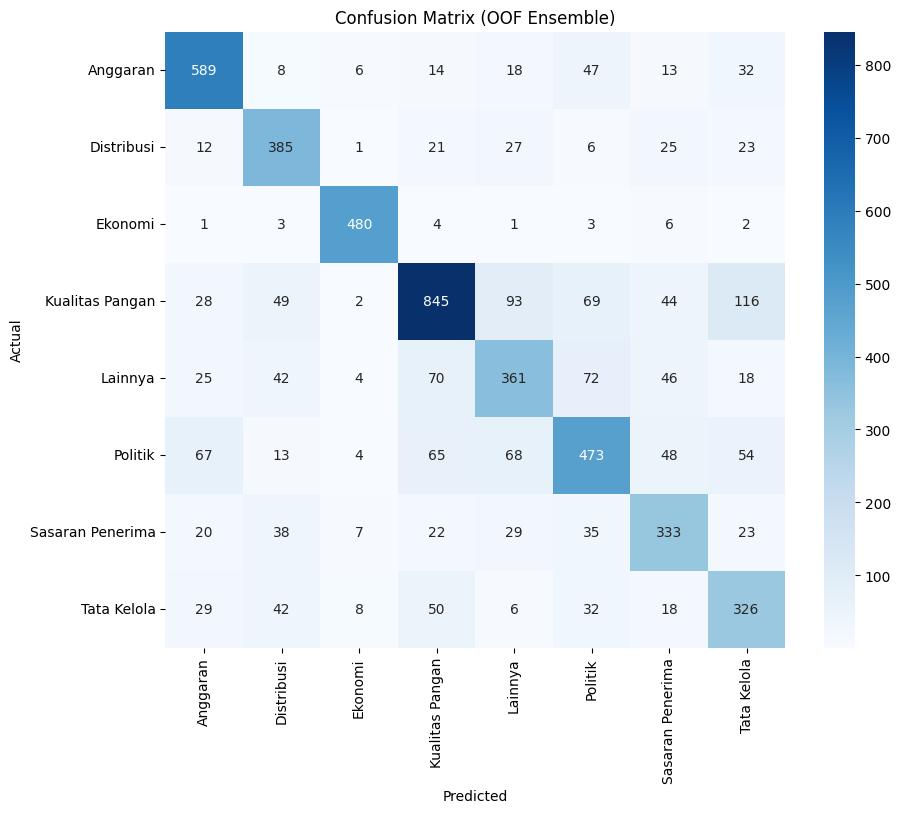

In [46]:
cm = confusion_matrix(all_val_labels, all_val_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_list, yticklabels=label_list, cmap='Blues')
plt.title('Confusion Matrix (OOF Ensemble)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
print("\nClassification Report (OOF):\n")
print(classification_report(all_val_labels, all_val_preds,
                           target_names=label_list, zero_division=0))


Classification Report (OOF):

                  precision    recall  f1-score   support

        Anggaran       0.76      0.81      0.79       727
      Distribusi       0.66      0.77      0.71       500
         Ekonomi       0.94      0.96      0.95       500
 Kualitas Pangan       0.77      0.68      0.72      1246
         Lainnya       0.60      0.57      0.58       638
         Politik       0.64      0.60      0.62       792
Sasaran Penerima       0.62      0.66      0.64       507
     Tata Kelola       0.55      0.64      0.59       511

        accuracy                           0.70      5421
       macro avg       0.69      0.71      0.70      5421
    weighted avg       0.70      0.70      0.70      5421



In [48]:
print("\nContoh kesalahan prediksi:")
errors = []
for i in range(len(all_val_labels)):
    if all_val_labels[i] != all_val_preds[i]:
        errors.append((X_aug[all_val_indices[i]], all_val_labels[i], all_val_preds[i]))

for j, (teks, true, pred) in enumerate(errors[:10]):
    print(f"\n{j+1}. True: {id2label[true]} | Pred: {id2label[pred]}")
    print(f"   Teks: {teks[:200]}...")


Contoh kesalahan prediksi:

1. True: Anggaran | Pred: Politik
   Teks: demo dimana mana, kejahatan ai meraja lela, pajak naik dengan pesat, dana pendidikan dipangkas dengan ekstrim cuma untuk mbg yg ga pernah ada berita bagusnya, janji kampanye belum ada yg terlaksana, b...

2. True: Anggaran | Pred: Tata Kelola
   Teks: gimana kalo konsumsi rapat pejabat juga disamakan kayak mbg?...

3. True: Anggaran | Pred: Kualitas Pangan
   Teks: [user] kmrn ngobrol dgn p3k yg urus mbg dia bilang hrg seporsi utk sd di 8rb &amp; 10rb utk smp...edun dpt mknan hrg segitu soal belatung kmrn kt ny berasal dr salak 😄 ada yg prnh ngeliat salah belatu...

4. True: Anggaran | Pred: Tata Kelola
   Teks: [user] [user] klaim prabowo bahwa program mbg menciptakan 290 ribu lapangan kerja didukung data pemerintah ([url] melibatkan dapur dan rantai pasok. namun, sumber kritis seperti [url] menyebutnya meny...

5. True: Anggaran | Pred: Tata Kelola
   Teks: tau gk yg masak mbg itu bayaran nya 120rb sehari dan itu

## Inference

In [49]:
class MBGPipeline:

    def __init__(self, id2label, device):
        self.id2label = id2label
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')
        self.model_paths = [f"./model_fold_{fold}" for fold in range(5)]

    def load_and_clean(self, file_path):
        df = pd.read_excel(file_path)[['id', 'full_text']]
        df['clean_text'] = df['full_text'].apply(clean_tweet)
        return df

    def predict(self, texts):
        all_logits = []
        for path in self.model_paths:
            model = AutoModelForSequenceClassification.from_pretrained(path)
            model.to(self.device)
            model.eval()

            dataset = TweetDataset(texts, [0]*len(texts), self.tokenizer)
            loader = torch.utils.data.DataLoader(dataset, batch_size=64)

            fold_logits = []
            with torch.no_grad():
                for batch in loader:
                    outputs = model(
                        input_ids=batch['input_ids'].to(self.device),
                        attention_mask=batch['attention_mask'].to(self.device)
                    )
                    fold_logits.append(outputs.logits.cpu().numpy())
            all_logits.append(np.concatenate(fold_logits, axis=0))
            del model
            torch.cuda.empty_cache()

        avg_logits = np.mean(all_logits, axis=0)
        preds = np.argmax(avg_logits, axis=-1)
        return preds

    def save(self, df, output_path='submission_ensemble.xlsx'):
        submission = df[['id', 'predicted_label']].rename(columns={'predicted_label': 'label'})
        submission.to_excel(output_path, index=False)
        return submission

    def run(self, file_path, output_path='submission_ensemble.xlsx'):
        df = self.load_and_clean(file_path)
        preds = self.predict(df['clean_text'].values)
        df['predicted_label'] = [self.id2label[p] for p in preds]
        return self.save(df, output_path)

pipeline = MBGPipeline(id2label, device)
hasil = pipeline.run('case_1_text_to_predict.xlsx', 'submission_ensemble.xlsx')


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7066.33it/s]
